<a href="https://colab.research.google.com/github/ACOELHO1976/MachineLearning/blob/main/mvp_ml_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Previsão de Cancelamento de Clientes (Churn)

## 🎯 Objetivo
O objetivo deste projeto é prever o **cancelamento de clientes (Churn)** em uma empresa de telecomunicações.

O termo **Churn** refere-se ao momento em que um cliente decide interromper o uso do serviço, ou seja, cancelar seu contrato.

## 📌 Tipo de problema
Este é um problema de **classificação binária**, onde:

- 1 → Cliente cancelou o serviço (Churn)
- 0 → Cliente permaneceu ativo

## 💡 Motivação
A perda de clientes impacta diretamente a receita da empresa. Identificar clientes com alto risco de cancelamento permite a aplicação de estratégias de retenção, como ofertas e melhorias no atendimento.

## 🤖 Por que usar Machine Learning?
O cancelamento de clientes depende de múltiplos fatores, como:
- tipo de contrato
- valor pago
- tempo de permanência

Modelos de Machine Learning conseguem identificar padrões complexos nesses dados e prever o comportamento futuro dos clientes.

## ⚠️ Premissas e limitações
- Os dados representam comportamento passado
- Não indicam causalidade, apenas correlação
- Dataset simulado (IBM)

## 📁 Dataset

- Fonte: IBM Telco Customer Churn
- Registros: ~7000 clientes
- Variável alvo: Cancelamento (Churn)

## 📌 Variáveis importantes
- tenure → Tempo como cliente
- MonthlyCharges → Valor mensal
- Contract → Tipo de contrato
- InternetService → Serviço de internet

## ⚠️ Limitações
- Dados simulados
- Pode não representar todos os cenários reais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

## 🔎 Análise exploratória

Nesta etapa analisamos a estrutura dos dados e padrões iniciais relacionados ao cancelamento de clientes.

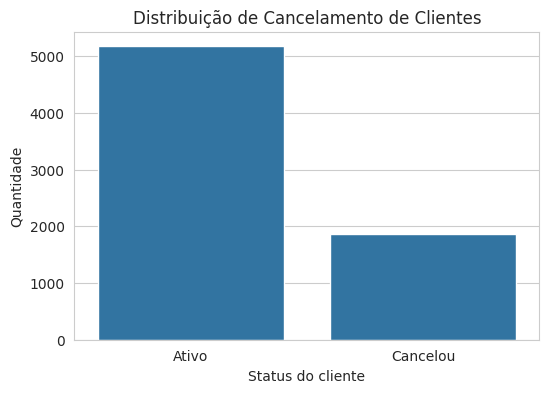

In [2]:
# Ajustando nomes para exibição
df_plot = df.copy()
df_plot['Churn'] = df_plot['Churn'].map({'Yes':'Cancelou', 'No':'Ativo'})

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df_plot)
plt.title('Distribuição de Cancelamento de Clientes')
plt.xlabel('Status do cliente')
plt.ylabel('Quantidade')
plt.show()

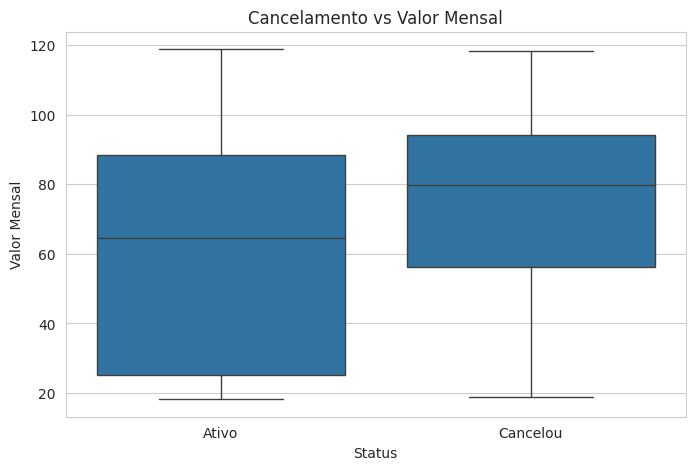

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_plot)
plt.title('Cancelamento vs Valor Mensal')
plt.xlabel('Status')
plt.ylabel('Valor Mensal')
plt.show()

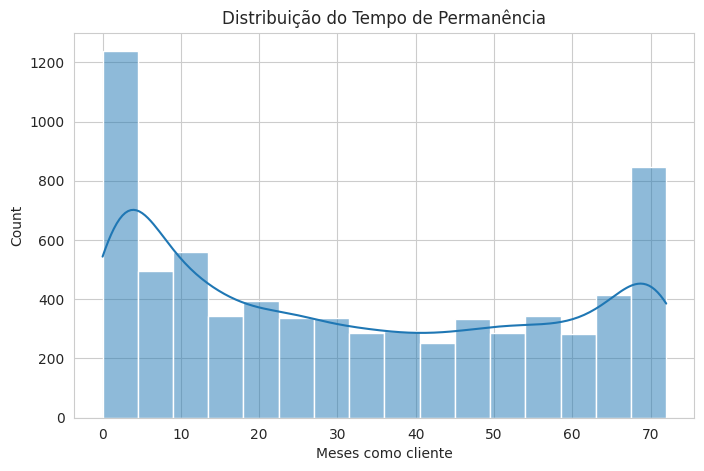

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], kde=True)
plt.title('Distribuição do Tempo de Permanência')
plt.xlabel('Meses como cliente')
plt.show()

## 📊 Insights

- Clientes com menor tempo tendem a cancelar mais
- Valores elevados estão associados a maior churn
- Existe leve desbalanceamento de classes

## 📊 Dashboard Analítico

Resumo visual dos principais fatores relacionados ao cancelamento.

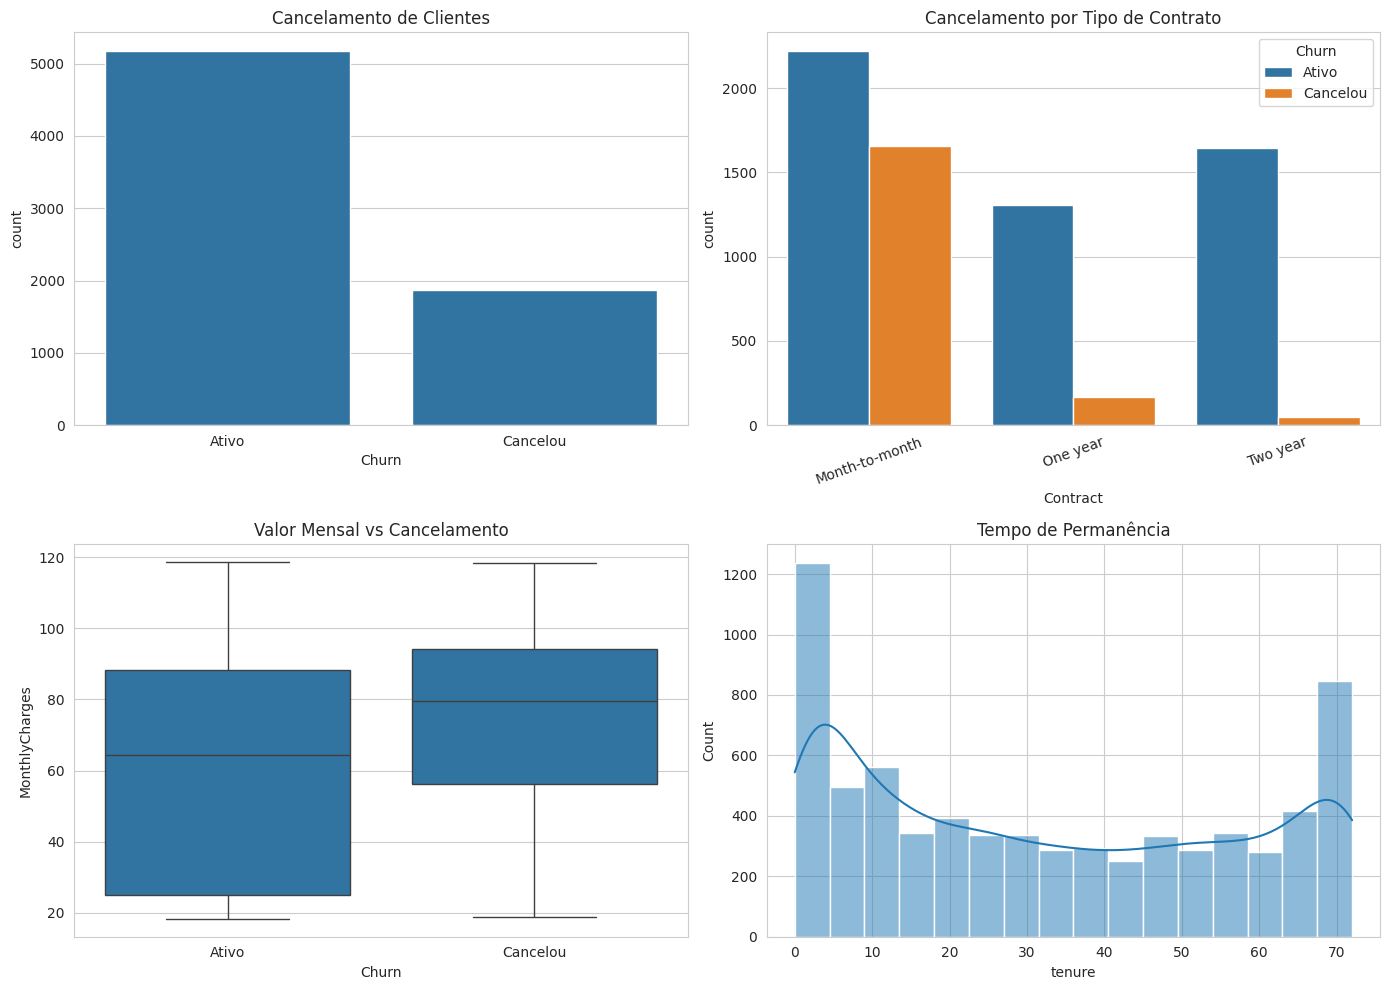

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

# Distribuição
sns.countplot(x='Churn', data=df_plot, ax=ax[0,0])
ax[0,0].set_title('Cancelamento de Clientes')

# Contrato
sns.countplot(x='Contract', hue='Churn', data=df_plot, ax=ax[0,1])
ax[0,1].set_title('Cancelamento por Tipo de Contrato')
ax[0,1].tick_params(axis='x', rotation=20)

# Valor mensal
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_plot, ax=ax[1,0])
ax[1,0].set_title('Valor Mensal vs Cancelamento')

# Tempo
sns.histplot(df['tenure'], kde=True, ax=ax[1,1])
ax[1,1].set_title('Tempo de Permanência')

plt.tight_layout()
plt.show()

## 📊 Interpretação

- Contratos mensais apresentam maior cancelamento  
- Clientes novos têm maior risco  
- Custos altos influenciam saída  

Esses fatores são críticos para estratégias de retenção.

## 🛠 Preparação dos dados

- Remoção de identificadores
- Conversão da variável alvo
- Encoding de variáveis categóricas
- Normalização

In [6]:
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🤖 Modelos

- Regressão Logística (baseline)
- Random Forest

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]})

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



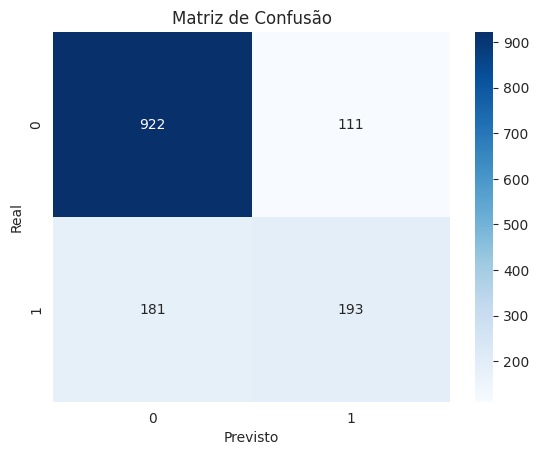

In [10]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

## 📊 Análise

- Random Forest teve melhor desempenho
- Modelo apresenta boa generalização
- Ainda há erros na detecção de cancelamento

## ⚠️ Limitações
- Pouca engenharia de atributos
- Dataset simples

## ✅ Conclusão

Este projeto desenvolveu um modelo para prever o cancelamento de clientes.

O modelo Random Forest apresentou o melhor desempenho, sendo capaz de identificar padrões importantes relacionados ao churn.

## 🚀 Próximos passos
- Testar modelos como XGBoost
- Melhorar features
- Ajustar hiperparâmetros de forma mais profunda

## 🎯 Conclusão final
O MVP atingiu seu objetivo e demonstra um pipeline completo de Machine Learning, desde a análise até a avaliação final.

## ✅ Checklist

- [x] Execução sem erros
- [x] Problema definido
- [x] Dataset carregado corretamente
- [x] Análise exploratória
- [x] Preparação adequada
- [x] Modelos treinados
- [x] Otimização aplicada
- [x] Avaliação completa
- [x] Conclusão clara